In [1]:
import re
import string
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.util import ngrams
from datetime import datetime
nltk.download('punkt')
import nltk
nltk.download('averaged_perceptron_tagger')
import nltk
nltk.download('wordnet')





[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
# Sample paragraph
text = """The Porsche 911 is a legendary sports car produced by the German automobile manufacturer Porsche AG. It has been in continuous production since 1963, making it one of the longest-running car models in history.
The 911 is known for its distinctive design, rear-engine layout, and high-performance capabilities. Over the years, it has undergone numerous updates and iterations, each one building upon the legacy of its predecessors.
Today, the Porsche 911 remains an icon of automotive engineering and a symbol of luxury and performance. As of 27-March-2000, it continues to uphold its reputation as a pinnacle of automotive excellence."""



In [3]:
# Count unique tokens
tokens = word_tokenize(text.lower())
unique_tokens = set(tokens)
print("Number of unique tokens:", len(unique_tokens))



Number of unique tokens: 68


In [4]:
# Count punctuation characters and remove punctuations
punctuation_count = sum([1 for char in text if char in string.punctuation])
text = re.sub(r'[^\w\s]', '', text)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


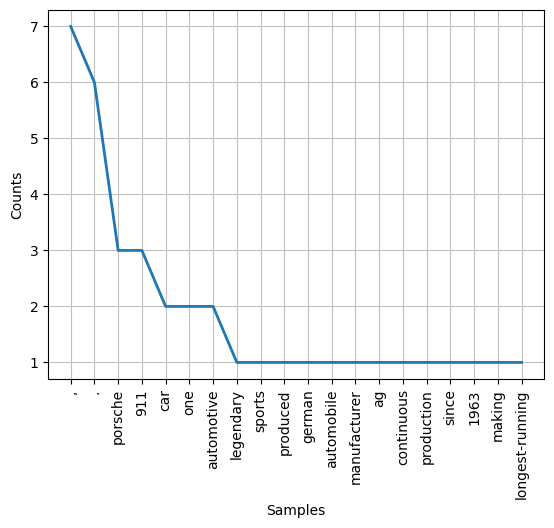

<Axes: xlabel='Samples', ylabel='Counts'>

In [5]:
# Plot distribution of stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
filtered_text = [word for word in tokens if word.lower() not in stop_words]
stopword_freq = nltk.FreqDist(filtered_text)
stopword_freq.plot(20, cumulative=False)



In [6]:
# Remove stopwords
filtered_text = [word for word in tokens if word.lower() not in stop_words]



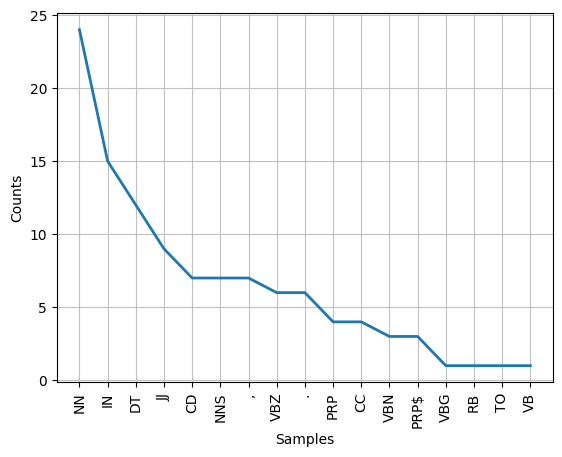

<Axes: xlabel='Samples', ylabel='Counts'>

In [7]:
# Plot distribution of POS tags
pos_tags = pos_tag(tokens)
pos_freq = nltk.FreqDist(tag for (word, tag) in pos_tags)
pos_freq.plot()



In [8]:
# Determine number of unique lemmas
lemmatizer = nltk.WordNetLemmatizer()
lemmas = [lemmatizer.lemmatize(word) for word in filtered_text]
unique_lemmas = set(lemmas)
print("Number of unique lemmas:", len(unique_lemmas))



Number of unique lemmas: 51


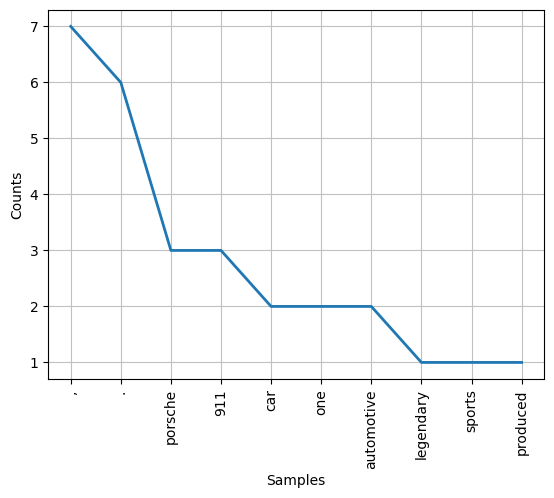

<Axes: xlabel='Samples', ylabel='Counts'>

In [9]:
# Plot frequency distribution of words
fdist = FreqDist(filtered_text)
fdist.plot(10)


In [10]:

# Find unique bigrams, trigrams, and quadgrams
bigrams = list(ngrams(filtered_text, 2))
trigrams = list(ngrams(filtered_text, 3))
quadgrams = list(ngrams(filtered_text, 4))
unique_bigrams = len(set(bigrams))
unique_trigrams = len(set(trigrams))
unique_quadgrams = len(set(quadgrams))
print("Number of unique bigrams:", unique_bigrams)
print("Number of unique trigrams:", unique_trigrams)
print("Number of unique quadgrams:", unique_quadgrams)



Number of unique bigrams: 67
Number of unique trigrams: 67
Number of unique quadgrams: 66


In [11]:
# Find and convert dates to DD-MM-YYYY format
dates = re.findall(r'\b(?:\d{1,2}[-/]\d{1,2}[-/]\d{2,4})\b', text)
dates_converted = [datetime.strptime(date, '%d-%B-%Y').strftime('%d-%m-%Y') for date in dates]
print("Converted dates:", dates_converted)



Converted dates: []


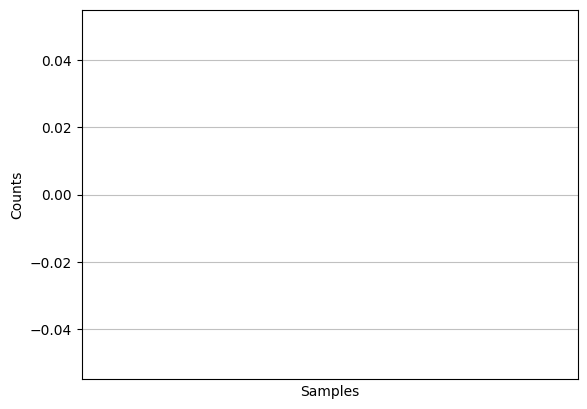

<Axes: xlabel='Samples', ylabel='Counts'>

In [12]:
# Plot distribution of years
years = [int(date.split('-')[2]) for date in dates_converted]
year_freq = nltk.FreqDist(years)
year_freq.plot()



In [13]:
# Determine if text contains phone numbers
phone_numbers = re.findall(r'[\+\(]?[1-9][0-9 .\-\(\)]{8,}[0-9]', text)
valid_phone_numbers = []
for number in phone_numbers:
    try:
        int(re.sub(r'[^\d]+', '', number))
        valid_phone_numbers.append(number)
    except ValueError:
        pass
if valid_phone_numbers:
    print("Valid phone numbers found:", valid_phone_numbers)
else:
    print("No valid phone numbers found.")

plt.show()


No valid phone numbers found.
